<a href="https://colab.research.google.com/github/aswathim3844/paatshala-assessment/blob/main/exit_exam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#importing libraries


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer


In [3]:

#loading data
data = pd.read_excel('/content/partpdf_1763620554909_eurovision_1998 to 2012.xlsx')


In [4]:
data.head(10)

,Unnamed: 0,Year,Country,Region,Artist,Song,Artist.gender,Group.Solo,Place,Points,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
0,1,2009,Lithuania,Former Socialist Bloc,Sasha Son,Love,Male,Solo,23,23,...,0.598360,102.984,0.027817,9.0,0.078643,3.0,0.0,-9.082,0.482059,6.148232
1,2,2009,Israel,Independent,Noa and Mira Awad,There Must Be Another Way,Female,Group,16,53,...,0.604542,105.972,0.024996,8.0,0.084805,4.0,1.0,-6.059,0.426209,5.141887
2,3,2009,France,Western Europe,Patricia Kaas,Et s'il fallait le faire,Female,Solo,8,107,...,0.367344,124.005,0.043751,1.0,0.923905,4.0,1.0,-8.655,0.292870,5.069762
3,4,2009,Sweden,Scandinavia,Malena Ernman,La voix,Female,Solo,21,33,...,0.513202,128.021,0.034855,10.0,0.143708,4.0,1.0,-4.536,0.206493,5.502692
4,5,2009,Croatia,Former Yugoslavia,Igor Cukrov feat. Andrea,Lijepa Tena,Both,Group,18,45,...,0.590592,116.107,0.032406,1.0,0.079322,4.0,0.0,-4.427,0.344541,NaN
5,6,2009,Portugal,Western Europe,Flor-de-Lis,Todas as ruas do amor,Both,Group,15,57,...,0.575144,96.966,0.042616,7.0,0.113280,4.0,1.0,-7.303,0.331690,4.976000
6,7,2009,Iceland,Scandinavia,Yohanna,Is It True?,Female,Solo,2,218,...,0.260856,83.978,0.030312,0.0,0.100348,4.0,0.0,-8.122,0.263602,5.215283
7,8,2009,Greece,Western Europe,Sakis Rouvas,This Is Our Night,Male,Solo,7,120,...,0.628108,127.920,0.064255,6.0,0.174562,4.0,0.0,-6.166,0.677573,NaN
8,9,2009,Armenia,Former Socialist Bloc,Inga and Anush,Jan Jan,Female,Group,10,92,...,0.691723,86.271,0.099743,4.0,0.356402,3.0,0.0,-4.061,0.736495,NaN
9,10,2009,Russia,Former Socialist Bloc,Anastasiya Prikhodko,Mamo,Female,Solo,11,91,...,0.631655,130.059,0.063436,2.0,0.186245,4.0,0.0,-4.202,0.650373,NaN


In [5]:
data.describe()

,Unnamed: 0,Year,Place,Points,Is.Final,Semi.Final.Number,Song.In.English,Song.Quality,Normalized.Points,energy,...,danceability,tempo,speechiness,key,liveness,time_signature,mode,loudness,valence,Happiness
count,648.000000,648.000000,648.000000,648.000000,648.000000,281.000000,648.000000,648.000000,648.000000,482.000000,...,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,482.000000,480.000000,304.000000
mean,324.500000,2006.543210,11.858025,77.783951,0.566358,1.327402,0.728395,2.636140,0.044753,0.725833,...,0.571246,113.905349,0.056576,5.782158,0.201399,3.900415,0.580913,-6.516718,0.521286,5.406843
std,187.205769,4.016733,6.795186,63.301464,0.495960,0.470103,0.445131,2.089733,0.034887,0.186675,...,0.136131,24.958535,0.050582,3.453922,0.172561,0.485164,0.493922,2.358372,0.236548,0.288879
min,1.000000,1998.000000,1.000000,0.000000,0.000000,1.000000,0.000000,-0.424200,0.000000,0.064730,...,0.183719,64.971000,0.023994,0.000000,0.026513,1.000000,0.000000,-21.878000,0.017786,4.375630
25%,162.750000,2004.000000,6.000000,30.000000,0.000000,1.000000,0.000000,1.017664,0.017946,0.607444,...,0.489436,91.968500,0.032869,2.250000,0.090076,4.000000,0.000000,-7.735000,0.328387,5.251099
50%,324.500000,2007.000000,12.000000,62.000000,1.000000,1.000000,1.000000,2.054728,0.035151,0.759969,...,0.574584,121.357500,0.041742,6.000000,0.136240,4.000000,1.000000,-6.169500,0.525902,5.464790
75%,486.250000,2010.000000,17.000000,110.000000,1.000000,2.000000,1.000000,3.864811,0.065451,0.881004,...,0.669654,130.163000,0.060256,9.000000,0.277933,4.000000,1.000000,-4.894000,0.723856,5.579380
max,648.000000,2012.000000,28.000000,387.000000,1.000000,2.000000,1.000000,9.795199,0.158867,0.999169,...,0.894179,211.985000,0.505107,11.000000,0.987510,7.000000,1.000000,-2.352000,0.971989,6.148232


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         648 non-null    int64  
 1   Year               648 non-null    int64  
 2   Country            648 non-null    object 
 3   Region             648 non-null    object 
 4   Artist             648 non-null    object 
 5   Song               648 non-null    object 
 6   Artist.gender      226 non-null    object 
 7   Group.Solo         226 non-null    object 
 8   Place              648 non-null    int64  
 9   Points             648 non-null    int64  
 10  Home.Away.Country  648 non-null    object 
 11  Home.Away.Region   648 non-null    object 
 12  Is.Final           648 non-null    int64  
 13  Semi.Final.Number  281 non-null    float64
 14  Song.In.English    648 non-null    int64  
 15  Song.Quality       648 non-null    float64
 16  Normalized.Points  648 non

In [7]:
data.shape

(648, 30)

In [8]:
data.isnull().sum()

,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,422
Group.Solo,422
Place,0
Points,0


In [9]:
mode_imputer=SimpleImputer(strategy='most_frequent')
knn_imputer = KNNImputer()


In [10]:
data[['Group.Solo','Artist.gender']] = mode_imputer.fit_transform(data[['Group.Solo','Artist.gender']])

In [11]:
data[['Happiness','valence','loudness','mode','time_signature','liveness','key','speechiness','tempo','danceability','acousticness','duration','energy','Semi.Final.Number']] = knn_imputer.fit_transform(data[['Happiness','valence','loudness','mode','time_signature','liveness','key','speechiness','tempo','danceability','acousticness','duration','energy','Semi.Final.Number']])

In [12]:
data.isnull().sum()



,0
Unnamed: 0,0
Year,0
Country,0
Region,0
Artist,0
Song,0
Artist.gender,0
Group.Solo,0
Place,0
Points,0


the data has missing value in many columns , i used simple imputer from sklearn using most_frequent strategy to handle missing value in categorical data and knnimputer to handle numerical columns , i used knn imputer because it will fill missing value with more accurate value using k-nearest neighbour search rather than filling with median or mean


In [13]:
#EDA

In [14]:
num_col = data.select_dtypes(include=['float64','int64'])

In [15]:
audio_features = data[[
        "energy",
        "duration",
        "acousticness",
        "danceability",
        "tempo",
        "speechiness",
        "key",
        "liveness",
        "time_signature",
        "mode",
        "loudness",
        "valence"
    ]
]

plotting heatmap

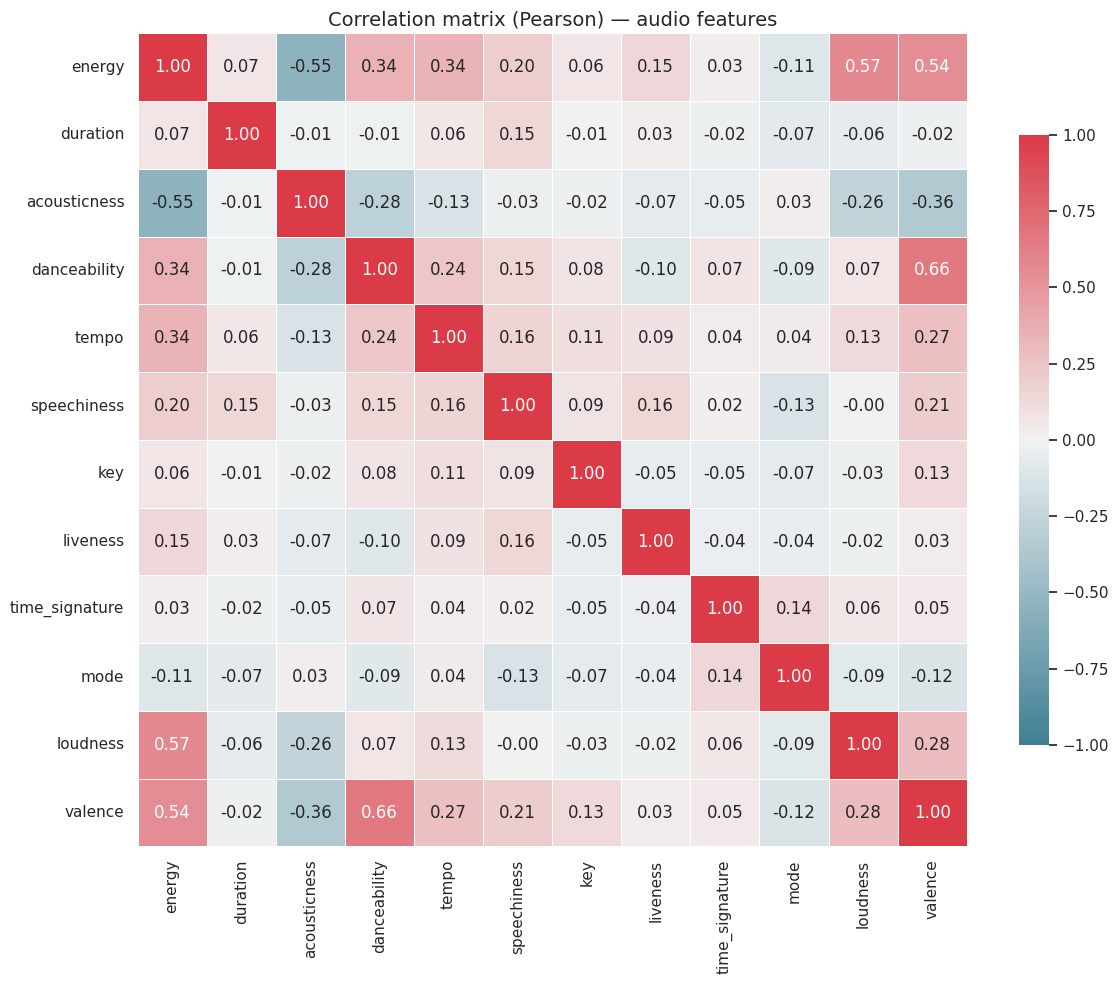

In [16]:
plt.figure(figsize=(12, 10))
sns.set(style="white")
cmap = sns.diverging_palette(220, 10, as_cmap=True)
corr = audio_features.corr(method="pearson")
sns.heatmap(
        corr,

        cmap=cmap,
        vmax=1.0,
        vmin=-1.0,
        center=0,
        annot=True,
        fmt=".2f",
        square=False,
        linewidths=.5,
        cbar_kws={"shrink": .75}
    )
plt.title("Correlation matrix (Pearson) — audio features", fontsize=14)
plt.tight_layout()



In [17]:
new_audio_features=data[["duration",
        'mode', "time_signature","liveness","speechiness","key",]]

selected new audio features are ["duration",
        ,'mode', "time_signature","liveness","speechiness","key",]

removed featuree are "energy",
      "danceability",
        "tempo",
        "acousticness"
        "loudness",
        "valence"


        removed energy because it showed high coorelation with valence and loudness
        removed danceability it showed high coorelation with valence and energy
        removed tempo as it showed high coorelation with energy
        removed "acousticness" as it showed high coorelation with energy
        

scatter plot

Text(0, 0.5, 'Points')

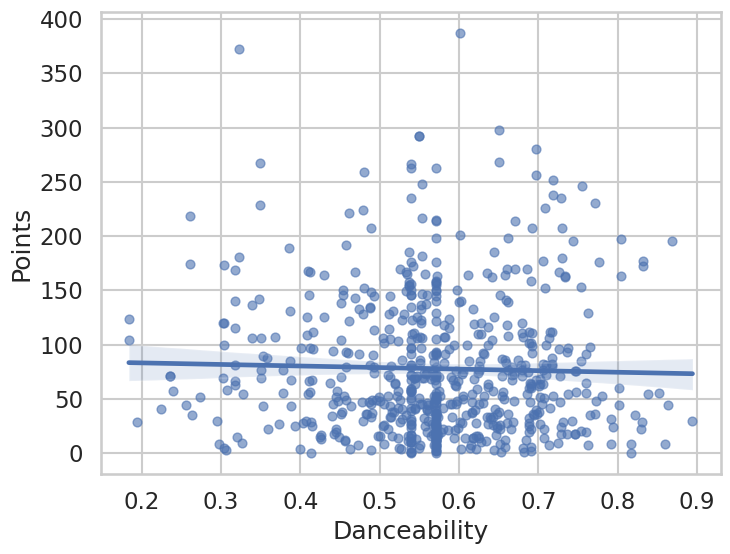

In [20]:
sns.set(style="whitegrid", context="talk")
plt.figure(figsize=(8,6))
ax = sns.regplot(
        x="danceability",
        y="Points",
        data=data,
        scatter_kws={"s":40, "alpha":0.6},
        marker="o"
    )
ax.set_xlabel("Danceability")
ax.set_ylabel("Points")



danceability alone seems to be a poor predictor of Points. Very danceable songs sometimes get high points and sometimes low points; likewise low-danceability songs sometimes score high.
: points are widely scattered across all danceability values (≈0.2–0.9) with no tight upward or downward cluster. The regression line is almost flat with a slight negative slope.
overall There is no clear positive relationship. The points are widely scattered across danceability values and the fitted line is almost flat (if anything, very slightly negative). So danceability alone appears to be a poor predictor of Eurovision Points.


splitting data

In [21]:
x=data[["duration",'mode', "time_signature","liveness","speechiness","key",]]
y=data['Points']



In [25]:
x.head(10)

,duration,mode,time_signature,liveness,speechiness,key
0,183.18476,0.0,3.0,0.078643,0.027817,9.0
1,179.87873,1.0,4.0,0.084805,0.024996,8.0
2,227.97333,1.0,4.0,0.923905,0.043751,1.0
3,178.45660,1.0,4.0,0.143708,0.034855,10.0
4,182.83057,0.0,4.0,0.079322,0.032406,1.0
5,253.46567,1.0,4.0,0.113280,0.042616,7.0
6,182.08762,0.0,4.0,0.100348,0.030312,0.0
7,176.47120,0.0,4.0,0.174562,0.064255,6.0
8,181.97333,0.0,3.0,0.356402,0.099743,4.0
9,170.56762,0.0,4.0,0.186245,0.063436,2.0


In [24]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [28]:
params = {
            "n_estimators": 200,
            "learning_rate": 0.1,
            "max_depth": 3,
            "random_state": 42,
            "loss": "ls",  # least squares
}

In [35]:
#training model
model = GradientBoostingRegressor()
model.fit(x_train, y_train)



GradientBoostingRegressor()

In [38]:
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test, y_pred)
print(f"  MAE  = {mae:.3f}  ")


  MAE  = 48.376  


we got a mae score of 48.376
which  means predictions are off, on average, by about 48 points.
if we had used any ensemble model like enadom forest along wity hyper paramter tuning using gridsearch cv we can reduce the mae


In [39]:
#saving as pickle

In [51]:
import pickle
from typing import Any
import os

def save_pickle(obj: Any, filepath: str, protocol: int = pickle.HIGHEST_PROTOCOL) -> None:
    """
    Save a picklable Python object to filepath.
    - obj: any picklable object (model, dict, DataFrame, etc.)
    - filepath: path to write (e.g. "models/gbr_model.pkl")
    """
    os.makedirs(os.path.dirname(filepath) or ".", exist_ok=True)
    with open(filepath, "wb") as f:
        pickle.dump(obj, f, protocol=protocol)
    print(f"Saved object to {filepath}")

In [55]:
if __name__ == "__main__":
    demo = {"hello": "world", "n": 1}
    save_pickle(demo, "demo_example.pkl")



Saved object to demo_example.pkl
